In [14]:
import fsrs
from datetime import datetime, timezone
import json
from tqdm import tqdm
from matplotlib import pyplot as plt

# https://raw.githubusercontent.com/open-spaced-repetition/srs-benchmark/0f70abe71ede66e27ee4c392a72998695ebc48b1/result/FSRS-6.jsonl
with open("FSRS-6-unclamped-decay.jsonl") as f:
    users = [json.loads(s) for s in f.readlines()]

dr = 0.7

In [28]:
example_ratings = {tuple(k): [] for k in [
    [3, 3, 3, 3],
    [3, 3],
    [1, 3, 3, 3],
    [1, 3],
    [1],
    [2],
    [3],
    [4]
]}

lower_bound = 0.05
upper_bound = 0.1

for user in tqdm(users):
    params = user["parameters"]["0"]
    decay = params[20]

    if lower_bound > decay or decay > upper_bound:
        continue

    sched = fsrs.Scheduler(params, learning_steps=(), relearning_steps=())
    sched.desired_retention = dr

    for ratings in example_ratings.keys():
        card = fsrs.Card()
        now = datetime.now(timezone.utc)
        for rating in ratings:
            last_review = now
            card, _ = sched.review_card(card, rating, now)
            now = card.due
        total_time = now - last_review
        example_ratings[ratings].append(total_time.days)
        

    

100%|██████████| 9999/9999 [00:11<00:00, 862.25it/s] 


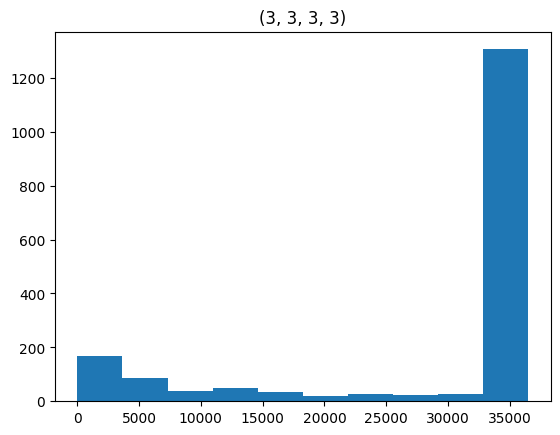

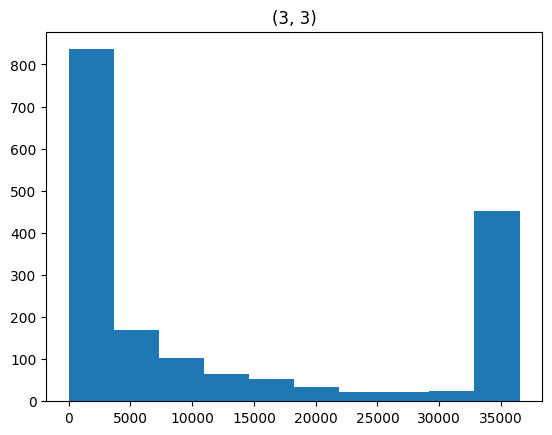

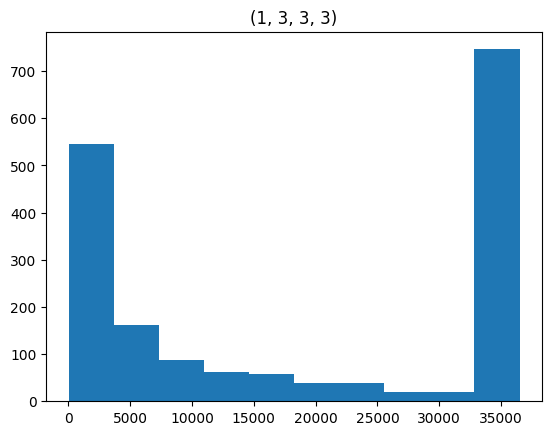

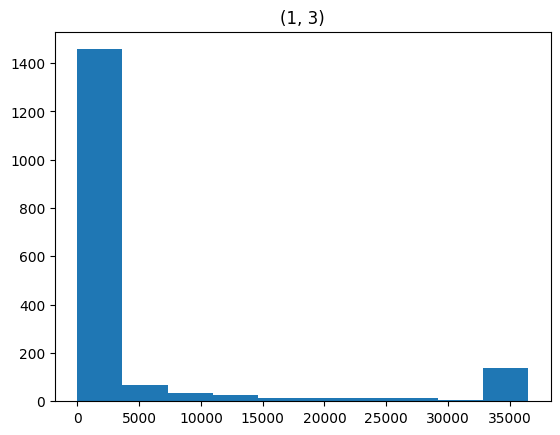

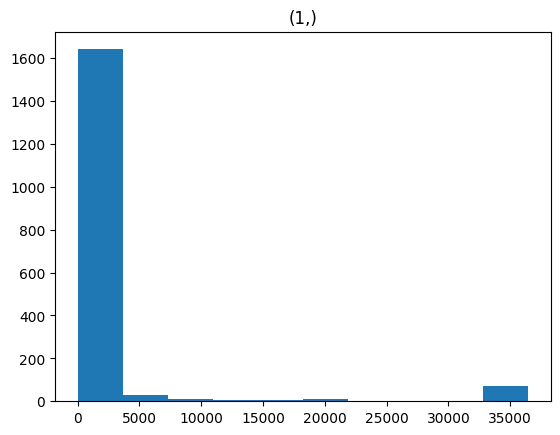

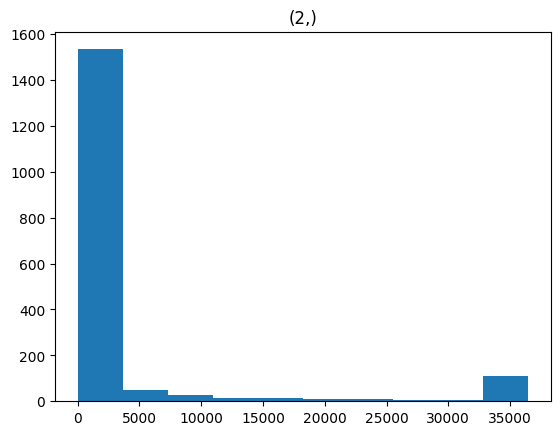

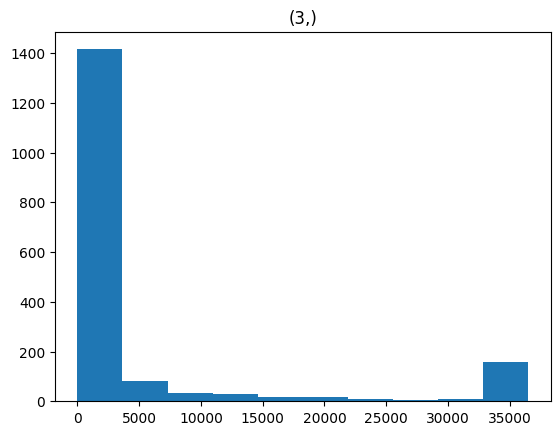

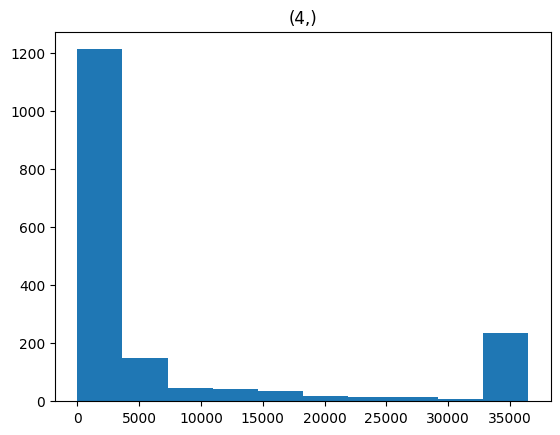

In [21]:
for key, val in example_ratings.items():
    plt.hist(val)
    plt.title(key)
    plt.show()